### Project Idea: Predict Students Marks Depends On Multiple Feature
Linear Regression


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [ ]:
# DATASET
# Features: [Hours Studied, Attendance Rate (%), IQ Score]
x = np.array( [
    [1, 70, 95],
    [2, 75, 100],
    [3, 80, 102],
    [4, 85, 105],
    [5, 90, 110],
    [6, 92, 108],
    [7, 95, 115],
    [8, 98, 120]
])
y = np.array([35, 50, 55, 70, 75, 88, 90, 95]) #marks

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


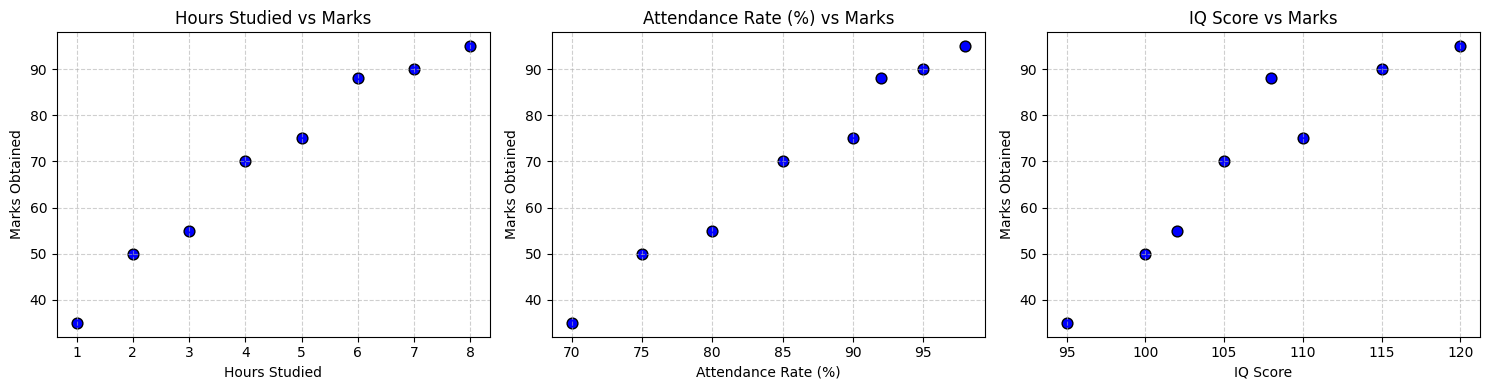

In [ ]:
#VISUALIZE DATASET

# Feature names for labeling our charts
feature_names = ['Hours Studied', 'Attendance Rate (%)', 'IQ Score']

# Create a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    # Scatter plot: Feature vs Marks
    axes[i].scatter(x[:, i], y, color='blue', s=60, edgecolors='k')
    axes[i].set_xlabel(feature_names[i])
    axes[i].set_ylabel('Marks Obtained')
    axes[i].set_title(f'{feature_names[i]} vs Marks')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
#Z-SCORE NORMALIZATION

def zscor (x):
    mu = np.mean(x,axis=0)
    sig = np.std(x,axis=0)
    xnorm = (x-mu)/sig
    return xnorm,mu,sig


In [ ]:
#IMPORTANT FUNCTIONS

## COST OF AN EXAMPLE
def cost (x,y,w,b):
    m = x.shape[0]
    sum =0
    for i in range(m):
        f = np.dot(x[i],w) + b
        c = (f-y[i])**2
        sum += c
    t = sum / (2*m)
    return t

#COMPUTE GRADIENT OF MULTIPLE FEATURES
def grad (x,y,w,b):
    m,n = x.shape
    dw = np.zeros(n)
    db =0.
    for i in range (m):
        err = (np.dot(x[i],w) + b) - y[i]
        for j in range (n):
            dw[j] += err*x[i,j]
        db += err
    dw /= m
    db /= m
    return dw,db

# GRADIENT DESCENT
def desc (x,y,w,b,cost,grad,alpha,num):
    j=[]
    for i in range (num):
        dw,db = grad (x,y,w,b)
        w -= alpha *dw
        b -= alpha *db

        if i <100000:
            j.append(cost(x,y,w,b))
        if i % math.ceil(num/10) == 10 :
            print(f'iterations:{i:4}, cost:{j[-1]:0.3e}')
    return w,b,j

#PREDICT VALUES
def compf (x,w,b):
    m = x.shape[0]
    f = np.zeros(m)
    for i in range (m):
        f[i] = np.dot(x[i], w) + b
    return f

#POLYNOMIAL FEATURES
def poly (x):
    return np.c_[x,x**2, x**3]

In [ ]:
#compute gradient descent to find the best w,b values

xnorm, mu,sig = zscor(x)
w = np.zeros(xnorm.shape[1])
b = 0.
num = 1000
alpha = 0.01
w,b,j = desc(xnorm,y,w,b,cost,grad,alpha,num)
print(f"W value:{w}, B value: {b}")



#show difference between actucal and predicted values:
f = compf (xnorm,w,b)
for i in range (xnorm.shape[0]):
    print(f"Predicted:{f[i]}, Actual:{y[i]}")

iterations:  10, cost:2.058e+03
iterations: 110, cost:2.692e+02
iterations: 210, cost:4.232e+01
iterations: 310, cost:1.164e+01
iterations: 410, cost:7.247e+00
iterations: 510, cost:6.391e+00
iterations: 610, cost:6.029e+00
iterations: 710, cost:5.751e+00
iterations: 810, cost:5.500e+00
iterations: 910, cost:5.268e+00
W value:[7.94098569 9.67810168 2.16819017], B value: 69.7469888054931
Predicted:37.95500154905187, Actual:35
Predicted:48.05386494596864, Actual:50
Predicted:57.29944056955585, Actual:55
Predicted:66.82944545091958, Actual:70
Predicted:76.92830884783635, Actual:75
Predicted:81.9095753478782, Actual:88
Predicted:90.4929025320552, Actual:90
Predicted:98.50737120067913, Actual:95


iterations:  10, cost:2.058e+03
iterations: 110, cost:2.692e+02
iterations: 210, cost:4.232e+01
iterations: 310, cost:1.164e+01
iterations: 410, cost:7.247e+00
iterations: 510, cost:6.391e+00
iterations: 610, cost:6.029e+00
iterations: 710, cost:5.751e+00
iterations: 810, cost:5.500e+00
iterations: 910, cost:5.268e+00
iterations:  10, cost:2.011e+03
iterations: 110, cost:2.708e+02
iterations: 210, cost:4.341e+01
iterations: 310, cost:1.217e+01
iterations: 410, cost:7.331e+00
iterations: 510, cost:6.127e+00
iterations: 610, cost:5.498e+00
iterations: 710, cost:5.019e+00
iterations: 810, cost:4.620e+00
iterations: 910, cost:4.284e+00
iterations:  10, cost:1.989e+03
iterations: 110, cost:2.717e+02
iterations: 210, cost:4.322e+01
iterations: 310, cost:1.135e+01
iterations: 410, cost:6.204e+00
iterations: 510, cost:4.893e+00
iterations: 610, cost:4.272e+00
iterations: 710, cost:3.865e+00
iterations: 810, cost:3.571e+00
iterations: 910, cost:3.352e+00


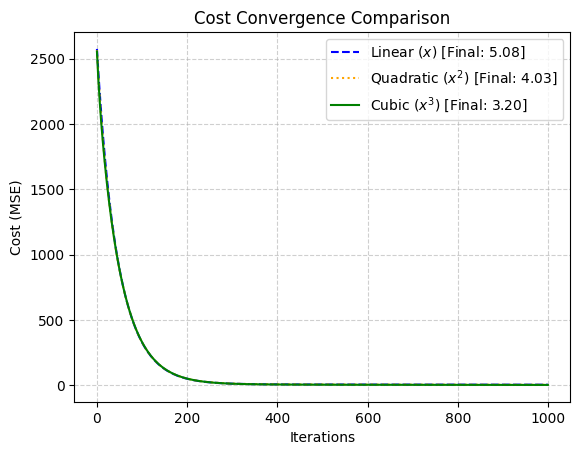

In [ ]:
# TRAIN ALL THREE MODELS
num = 1000
alpha = 0.01

# 1. Linear (x)
xnorm1, _, _ = zscor(x)
w1, b1, j1 = desc(
    xnorm1, y, np.zeros(xnorm1.shape[1]), 0.0, cost, grad, alpha, num
)

# 2. Quadratic (x, x^2)
x_poly2 = np.c_[x, x ** 2]
xnorm2, _, _ = zscor(x_poly2)
w2, b2, j2 = desc(
    xnorm2, y, np.zeros(xnorm2.shape[1]), 0.0, cost, grad, alpha, num
)

# 3. Cubic (x, x^2, x^3)
x_poly3 = np.c_[x, x ** 2, x ** 3]
xnorm3, _, _ = zscor(x_poly3)
w3, b3, j3 = desc(
    xnorm3, y, np.zeros(xnorm3.shape[1]), 0.0, cost, grad, alpha, num
)


# 1. Cost Convergence Plot
plt.plot(j1, label=f'Linear ($x$) [Final: {j1[-1]:.2f}]', color='blue', linestyle='--')
plt.plot(
    j2, label=f'Quadratic ($x^2$) [Final: {j2[-1]:.2f}]', color='orange', linestyle=':'
)
plt.plot(j3, label=f'Cubic ($x^3$) [Final: {j3[-1]:.2f}]', color='green')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Cost Convergence Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
